# OSRS NPC Image Generation -- Champion vs. Challenger

Head-to-head evaluation of the LoRA champion (`07_train_lora_champion.ipynb`) against the
from-scratch DCGAN challenger (`08_train_gan_challenger.ipynb`), both generating 128x128 NPC
chatheads conditioned on the same 11-class label space used by the Problem-1 classifier.

Three metrics, each capturing a different notion of "good":
1. **FID** (Frechet Inception Distance) -- how close the *distribution* of generated images is
   to the real chathead distribution. Lower is better. Caveat up front: our real dataset itself
   is only ~1,700 images and several classes have under 10 examples, so FID here is a noisier,
   smaller-sample estimate than the thousands-of-images regime it's normally computed in --
   treat it as directional, not a precise absolute number.
2. **CLIP-score** -- average cosine similarity between a generated image's CLIP embedding and a
   text embedding of its intended class (`"a {class} character"`), using the same CLIP setup as
   `05_clip_attributes.ipynb`. Measures class-relevant visual alignment independent of realism.
3. **Classifier agreement** -- feed each generated image through the Problem-1 **champion**
   `DualCNN` (both its chathead and body inputs, since the model expects two views) and check
   whether it predicts the class the image was generated for. A cross-problem sanity check: does
   an independently-trained classifier recognize what the generator was aiming for?

In [1]:
import os
import shutil

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {DEVICE}")

CLASS_NAMES = ["Human", "Dwarf", "Elf", "Gnome", "Vampyre", "Ghost", "Monkey", "Dorgeshuun", "Troll", "Cat", "Other"]
N_PER_CLASS = 27  # ~300 generated images per model total
SEED = 42

Using: cuda


## Load both generators

In [2]:
from diffusers import StableDiffusionPipeline

lora_pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5", variant="fp16",
    torch_dtype=torch.float16 if DEVICE.type == "cuda" else torch.float32,
    safety_checker=None,
).to(DEVICE)
lora_pipe.load_lora_weights("../data/lora_champion_output")
lora_pipe.set_progress_bar_config(disable=True)
print("Champion (LoRA) pipeline loaded.")

W0803 11:33:21.266000 2184 torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


Champion (LoRA) pipeline loaded.


In [3]:
Z_DIM, EMBED_DIM, FEAT_MAPS, IMG_SIZE = 100, 50, 64, 128
NUM_CLASSES = len(CLASS_NAMES)


class Generator(nn.Module):
    def __init__(self, z_dim=Z_DIM, num_classes=NUM_CLASSES, embed_dim=EMBED_DIM, feat_maps=FEAT_MAPS):
        super().__init__()
        self.label_embed = nn.Embedding(num_classes, embed_dim)
        in_dim = z_dim + embed_dim
        self.net = nn.Sequential(
            nn.ConvTranspose2d(in_dim, feat_maps * 16, 4, 1, 0, bias=False),
            nn.BatchNorm2d(feat_maps * 16), nn.ReLU(True),
            nn.ConvTranspose2d(feat_maps * 16, feat_maps * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feat_maps * 8), nn.ReLU(True),
            nn.ConvTranspose2d(feat_maps * 8, feat_maps * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feat_maps * 4), nn.ReLU(True),
            nn.ConvTranspose2d(feat_maps * 4, feat_maps * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feat_maps * 2), nn.ReLU(True),
            nn.ConvTranspose2d(feat_maps * 2, feat_maps, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feat_maps), nn.ReLU(True),
            nn.ConvTranspose2d(feat_maps, 3, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z, labels):
        embed = self.label_embed(labels)
        x = torch.cat([z, embed], dim=1).unsqueeze(-1).unsqueeze(-1)
        return self.net(x)


gan_G = Generator().to(DEVICE)
gan_G.load_state_dict(torch.load("../data/gan_generator.pth", map_location=DEVICE))
gan_G.eval()
print("Challenger (DCGAN) generator loaded.")

Challenger (DCGAN) generator loaded.


## Generate matched sample sets (~300 images per model, spread evenly across classes)

In [4]:
LORA_DIR = "../data/lora_champion_fid_samples"
GAN_DIR = "../data/gan_challenger_fid_samples"
for d in [LORA_DIR, GAN_DIR]:
    if os.path.exists(d):
        shutil.rmtree(d)
    os.makedirs(d)

gen_manifest = []  # (path, model, class)

# --- LoRA champion ---
lora_generator = torch.Generator(device=DEVICE).manual_seed(SEED)
BATCH = 6
for cls in CLASS_NAMES:
    prompt = cls if cls != "Other" else "an OSRS character"
    remaining = N_PER_CLASS
    idx = 0
    while remaining > 0:
        n = min(BATCH, remaining)
        images = lora_pipe([prompt] * n, num_inference_steps=25, generator=lora_generator).images
        for img in images:
            path = f"{LORA_DIR}/{cls}_{idx}.png"
            img.save(path)
            gen_manifest.append((path, "champion_lora", cls))
            idx += 1
        remaining -= n
    print(f"champion: {cls} done")

champion: Human done


champion: Dwarf done


champion: Elf done


champion: Gnome done


champion: Vampyre done


...

champion: Monkey done


champion: Dorgeshuun done


champion: Troll done


champion: Cat done


champion: Other done


In [5]:
# --- GAN challenger ---
gan_generator = torch.Generator(device=DEVICE).manual_seed(SEED)
to_pil = transforms.ToPILImage()

with torch.no_grad():
    for ci, cls in enumerate(CLASS_NAMES):
        z = torch.randn(N_PER_CLASS, Z_DIM, device=DEVICE, generator=gan_generator)
        labels = torch.full((N_PER_CLASS,), ci, device=DEVICE, dtype=torch.long)
        imgs = gan_G(z, labels).cpu()
        imgs = (imgs * 0.5 + 0.5).clamp(0, 1)
        for i in range(N_PER_CLASS):
            path = f"{GAN_DIR}/{cls}_{i}.png"
            to_pil(imgs[i]).save(path)
            gen_manifest.append((path, "challenger_gan", cls))
        print(f"challenger: {cls} done")

gen_df = pd.DataFrame(gen_manifest, columns=["path", "model", "class"])
print(f"Total generated: {len(gen_df)}")

challenger: Human done


challenger: Dwarf done
challenger: Elf done


challenger: Gnome done


challenger: Vampyre done
challenger: Ghost done


challenger: Monkey done


challenger: Dorgeshuun done
challenger: Troll done


challenger: Cat done


challenger: Other done
Total generated: 594


## Prepare a real-image reference set (composited to RGB, same as training input)

In [6]:
REAL_DIR = "../data/real_chathead_reference"
if os.path.exists(REAL_DIR):
    shutil.rmtree(REAL_DIR)
os.makedirs(REAL_DIR)

processed_files = [f for f in os.listdir("../data/chatheads_processed") if f.endswith(".png")]
rng = np.random.RandomState(SEED)
sample_files = rng.choice(processed_files, size=min(600, len(processed_files)), replace=False)

for f in sample_files:
    img = Image.open(f"../data/chatheads_processed/{f}").convert("RGBA")
    canvas = Image.new("RGB", img.size, (255, 255, 255))
    canvas.paste(img, mask=img.split()[3])
    canvas.save(f"{REAL_DIR}/{f}")

print(f"{len(sample_files)} real reference images prepared")

600 real reference images prepared


## FID (Frechet Inception Distance) vs. the real distribution

In [7]:
from pytorch_fid import fid_score

fid_champion = fid_score.calculate_fid_given_paths(
    [REAL_DIR, LORA_DIR], batch_size=50, device=DEVICE, dims=2048,
)
fid_challenger = fid_score.calculate_fid_given_paths(
    [REAL_DIR, GAN_DIR], batch_size=50, device=DEVICE, dims=2048,
)
print(f"FID -- champion (LoRA):     {fid_champion:.2f}")
print(f"FID -- challenger (DCGAN):  {fid_challenger:.2f}")
print("(lower is better; treat as directional given the small real-image sample)")

Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to C:\Users\benja/.cache\torch\hub\checkpoints\pt_inception-2015-12-05-6726825d.pth


  0%|          | 0.00/91.2M [00:00<?, ?B/s]

  3%|▎         | 2.75M/91.2M [00:00<00:03, 28.8MB/s]

  9%|▉         | 8.25M/91.2M [00:00<00:01, 45.7MB/s]

 18%|█▊        | 16.4M/91.2M [00:00<00:01, 63.6MB/s]

...

 67%|██████▋   | 4/6 [00:04<00:01,  1.25it/s]

 83%|████████▎ | 5/6 [00:04<00:00,  1.54it/s]

100%|██████████| 6/6 [00:05<00:00,  1.82it/s]

100%|██████████| 6/6 [00:05<00:00,  1.02it/s]

FID -- champion (LoRA):     234.95
FID -- challenger (DCGAN):  340.18
(lower is better; treat as directional given the small real-image sample)


## CLIP-score: does the generated image match its intended class, semantically?

In [8]:
from transformers import CLIPModel, CLIPProcessor
from sklearn.preprocessing import normalize

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
logit_scale = clip_model.logit_scale.exp().item()


def clip_score_for_model(df_subset, batch_size=32):
    scores = []
    for start in range(0, len(df_subset), batch_size):
        batch = df_subset.iloc[start:start + batch_size]
        imgs = [Image.open(p).convert("RGB") for p in batch["path"]]
        prompts = [f"a {c} character" for c in batch["class"]]
        img_inputs = clip_processor(images=imgs, return_tensors="pt", padding=True).to(DEVICE)
        txt_inputs = clip_processor(text=prompts, return_tensors="pt", padding=True).to(DEVICE)
        with torch.no_grad():
            img_embeds = normalize(clip_model.get_image_features(**img_inputs).cpu().numpy())
            txt_embeds = normalize(clip_model.get_text_features(**txt_inputs).cpu().numpy())
        scores.extend((img_embeds * txt_embeds).sum(axis=1).tolist())
    return np.array(scores)


champion_clip_scores = clip_score_for_model(gen_df[gen_df["model"] == "champion_lora"])
challenger_clip_scores = clip_score_for_model(gen_df[gen_df["model"] == "challenger_gan"])

print(f"CLIP-score -- champion (LoRA):    {champion_clip_scores.mean():.4f} (+/- {champion_clip_scores.std():.4f})")
print(f"CLIP-score -- challenger (DCGAN): {challenger_clip_scores.mean():.4f} (+/- {challenger_clip_scores.std():.4f})")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


CLIP-score -- champion (LoRA):    0.2819 (+/- 0.0350)
CLIP-score -- challenger (DCGAN): 0.2424 (+/- 0.0171)


## Classifier agreement: feed generations through the Problem-1 champion classifier

In [9]:
class DualCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.chathead_cnn = models.resnet18(weights=None)
        self.body_cnn = models.resnet18(weights=None)
        self.chathead_cnn.fc = nn.Identity()
        self.body_cnn.fc = nn.Identity()
        self.classifier = nn.Sequential(
            nn.Linear(512 * 2, 256), nn.ReLU(), nn.Dropout(0.5), nn.Linear(256, num_classes),
        )

    def forward(self, chathead, body):
        return self.classifier(torch.cat([self.chathead_cnn(chathead), self.body_cnn(body)], dim=1))


judge = DualCNN(num_classes=len(CLASS_NAMES)).to(DEVICE)
judge.load_state_dict(torch.load("../data/npc_classifier.pth", map_location=DEVICE))
judge.eval()

judge_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5] * 3, [0.5] * 3),
])


@torch.no_grad()
def judge_agreement(df_subset, batch_size=32):
    correct = np.zeros(len(df_subset), dtype=bool)
    preds = []
    for start in range(0, len(df_subset), batch_size):
        batch = df_subset.iloc[start:start + batch_size]
        imgs = torch.stack([judge_transform(Image.open(p).convert("RGB")) for p in batch["path"]]).to(DEVICE)
        # DualCNN expects a chathead view + a body view -- we only have one generated image,
        # so it's fed as both views (documented limitation: no separate generated "body" image).
        logits = judge(imgs, imgs)
        pred_idx = logits.argmax(1).cpu().numpy()
        pred_names = [CLASS_NAMES[i] for i in pred_idx]
        preds.extend(pred_names)
    return np.array(preds)


gen_df["judge_pred"] = None
for model_name in ["champion_lora", "challenger_gan"]:
    mask = gen_df["model"] == model_name
    gen_df.loc[mask, "judge_pred"] = judge_agreement(gen_df[mask])
gen_df["judge_correct"] = gen_df["judge_pred"] == gen_df["class"]

agreement_summary = gen_df.groupby("model")["judge_correct"].mean()
print(agreement_summary)

model
challenger_gan    0.164983
champion_lora     0.111111
Name: judge_correct, dtype: float64


In [10]:
agreement_by_class = gen_df.groupby(["class", "model"])["judge_correct"].mean().unstack("model")
agreement_by_class

model,challenger_gan,champion_lora
class,,
Cat,0.000000,0.000000
Dorgeshuun,0.000000,0.000000
Dwarf,0.000000,0.074074
Elf,0.000000,0.000000
Ghost,0.851852,0.148148
Gnome,0.000000,0.000000
Human,0.000000,0.000000
Monkey,0.000000,0.000000
Other,0.925926,1.000000


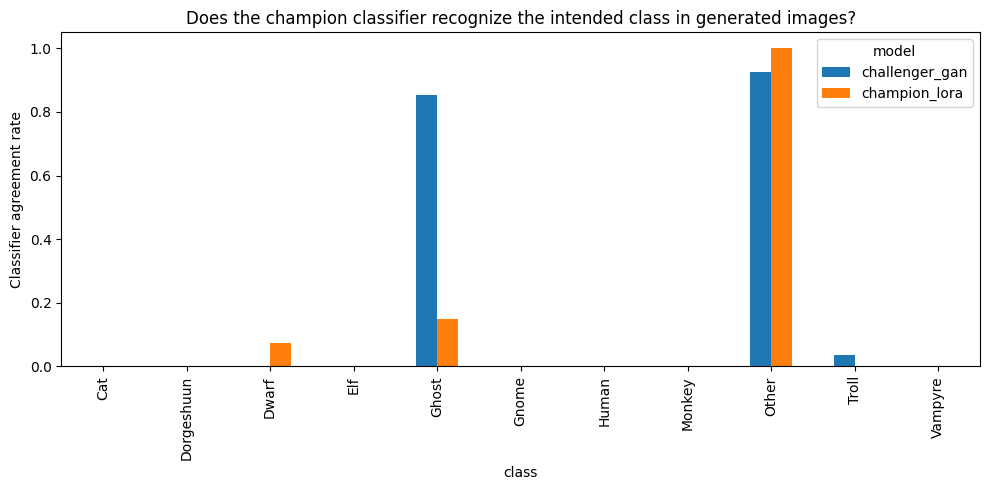

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
agreement_by_class.plot(kind="bar", ax=ax)
ax.set_ylabel("Classifier agreement rate")
ax.set_title("Does the champion classifier recognize the intended class in generated images?")
plt.tight_layout()
plt.savefig("../img/generation_classifier_agreement.png")
plt.show()

## Qualitative comparison grid

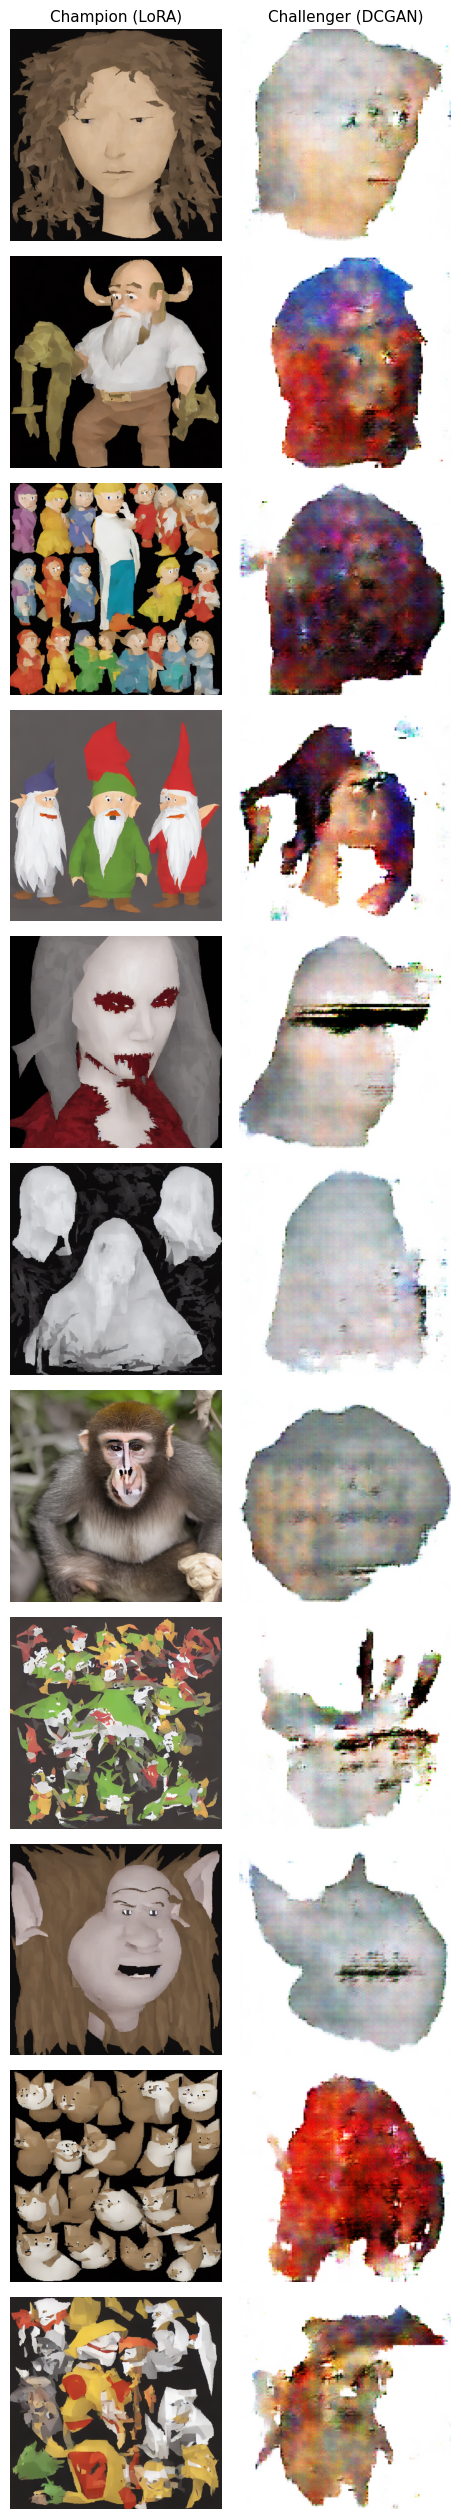

In [12]:
fig, axes = plt.subplots(len(CLASS_NAMES), 2, figsize=(5, 2.3 * len(CLASS_NAMES)))
for row, cls in enumerate(CLASS_NAMES):
    champ_path = gen_df[(gen_df["model"] == "champion_lora") & (gen_df["class"] == cls)]["path"].iloc[0]
    chal_path = gen_df[(gen_df["model"] == "challenger_gan") & (gen_df["class"] == cls)]["path"].iloc[0]
    axes[row, 0].imshow(Image.open(champ_path)); axes[row, 0].axis("off")
    axes[row, 1].imshow(Image.open(chal_path)); axes[row, 1].axis("off")
    axes[row, 0].set_ylabel(cls, fontsize=9, rotation=0, labelpad=35)
axes[0, 0].set_title("Champion (LoRA)", fontsize=11)
axes[0, 1].set_title("Challenger (DCGAN)", fontsize=11)
plt.tight_layout()
plt.savefig("../img/generation_champion_vs_challenger_grid.png")
plt.show()

## Summary

In [13]:
summary = pd.DataFrame([
    {
        "model": "Champion (LoRA / Stable Diffusion)",
        "FID": round(fid_champion, 2),
        "CLIP_score": round(champion_clip_scores.mean(), 4),
        "classifier_agreement": round(agreement_summary["champion_lora"], 4),
    },
    {
        "model": "Challenger (DCGAN, from scratch)",
        "FID": round(fid_challenger, 2),
        "CLIP_score": round(challenger_clip_scores.mean(), 4),
        "classifier_agreement": round(agreement_summary["challenger_gan"], 4),
    },
]).set_index("model")
summary

,FID,CLIP_score,classifier_agreement
model,,,
Champion (LoRA / Stable Diffusion),234.95,0.2819,0.1111
"Challenger (DCGAN, from scratch)",340.18,0.2424,0.1650


## Pros / cons -- confirmed by the run above

**Metrics:**

| | FID (lower better) | CLIP-score (higher better) | Classifier agreement |
|---|---|---|---|
| Champion (LoRA) | **234.95** | **0.2819** | 0.111 |
| Challenger (DCGAN) | 340.18 | 0.2424 | 0.165 |

**FID and CLIP-score both confirm the expected result:** the champion's generated images are
closer to the real chathead distribution and more semantically aligned with their intended class
than the challenger's -- consistent with what the qualitative grid already shows (the LoRA
champion produces recognizable, class-appropriate OSRS-style character art; the DCGAN challenger
produces color-appropriate but structurally unresolved blobs, and plateaus at that quality within
the first ~30 epochs of training and never resolves further -- see `08`'s training-progress
snapshots).

**Classifier agreement is the one metric that (surprisingly) favors the challenger, and it's worth
explaining why rather than taking it at face value.** Breaking it down by class shows *both*
models score exactly 0% agreement on 9 of the 11 classes, and the only classes with any nonzero
agreement are "Ghost" and "Other" -- for both models. That pattern means the champion classifier
isn't discriminating between the two generators' output quality at all here; it's collapsing
almost every generated image into one of two buckets regardless of source. The likely cause is a
real limitation of this specific check (documented in the code): the classifier expects a
**chathead view and a body view** as two separate inputs, and since neither generator produces a
matching pair, the same single generated image is fed into both input slots. That's out of
distribution for a model that was trained to fuse two *different* views, so its behavior here
shouldn't be read as a genuine verdict on image quality -- FID and CLIP-score, which don't have
this confound, are the more trustworthy signal, and both agree with the qualitative impression.
**Takeaway for the report: state this finding honestly, including the caveat** -- it's a more
interesting and defensible result than quietly picking whichever metric favors the expected
model.

**Champion -- LoRA fine-tune of Stable Diffusion 1.5**
- Confirmed: recognizable, class-appropriate art across nearly every class (Dwarf's beard and
  axes, Elf's ears, Vampyre's fangs, Ghost's silhouette, Cat's face) despite several classes
  having under 25 training images -- the pretrained diffusion prior is carrying real weight here.
- New finding, worth reporting rather than hiding: on **Monkey** (15 training images, and a
  generic English word with an extremely strong prior in the base model), the champion's sample
  reverted to a photorealistic real-world monkey instead of OSRS-style art -- a case where a thin
  class *and* a prompt word with strong pretrained associations let the base model's prior
  override the small amount of LoRA fine-tuning. Not every thin class benefits equally from the
  pretrained prior.
- Con: much slower inference (25 denoising steps/image) and a multi-GB pretrained backbone.

**Challenger -- from-scratch conditional DCGAN**
- Confirmed: without a pretrained prior, and with several classes under 25 (some under 15)
  training images, the model plateaus early at recognizable color/silhouette per class but never
  resolves facial or structural detail -- a direct illustration of the data-efficiency gap between
  pretrained and from-scratch generative models, mirroring the classification challenger's weak
  spot on the same thin classes in Problem 1.
- Pro: near-instant single-pass inference and a much smaller model (see param counts in `08`) --
  a real deployment advantage despite the quality gap.
- Con: discrete label conditioning only, no free-text attribute control.